Name:- Kanhaiya Uttam Naik

Roll No:-CS37

Aim:-To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

Objectives:

- Understand SLR

- Load/preprocess dataset

- perform EDA
- Compute OLS coefficients
- Evaluate with SSE, MSE, R²
- Visualize regression and residual plots


Software Requirements:
- Python 3.x
- Jupyter/Colab/VS Code
- Libraries: pandas, numpy, matplotlib, seaborn


Theory:
Linear regression models the relationship between a target continuous variable Y and
an input feature vector X using a linear equation:
          
           yˆ=w0+w1x1


In matrix form, including the bias/intercept term X0=1:

               yˆ=Xw


To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method
minimizes the Sum of Squared Errors (SSE) between actual target values y and
predicted values yˆ:

       SSE=i=1Nyi-yˆi2=y-XwTy-Xw


Solving for w analytically yields the normal equation:
            
             wˆ=XTX-1XTy


Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant
is non-zero).


Algorithm:
1. Import libraries
2. Load Auto MPG dataset
3. Inspect and clean data
4. Select horsepower and mpg
5. Plot scatter graph
6. Add bias term
7. Compute correlation
8. Calculate OLS weights
9. Predict values
10. Compute residuals
11. Calculate SSE, MSE, R²
12. Plot regression and residual graphs
13. Interpret results.
14. Upload the google colab onto Git hub repository

In [ ]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

In [ ]:
# TASK 2: LOAD AUTO MPG DATASET

from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving auto-mpg.csv to auto-mpg (1).csv
Dataset loaded successfully!
Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
# TASK 3: INSPECT AND CLEAN DATA

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

First 5 Rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



Statistical Summary:


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
# TASK 4: SELECT HORSEPOWER AND MPG

X = df['horsepower'].values
y = df['mpg'].values

print("Input feature: Horsepower")
print("Target variable: MPG")

print("\nNumber of observations:", len(X))

print("\nFirst 10 Horsepower values:")
print(X[:10])

print("\nFirst 10 MPG values:")
print(y[:10])

Input feature: Horsepower
Target variable: MPG

Number of observations: 398

First 10 Horsepower values:
['130' '165' '150' '150' '140' '198' '220' '215' '225' '190']

First 10 MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


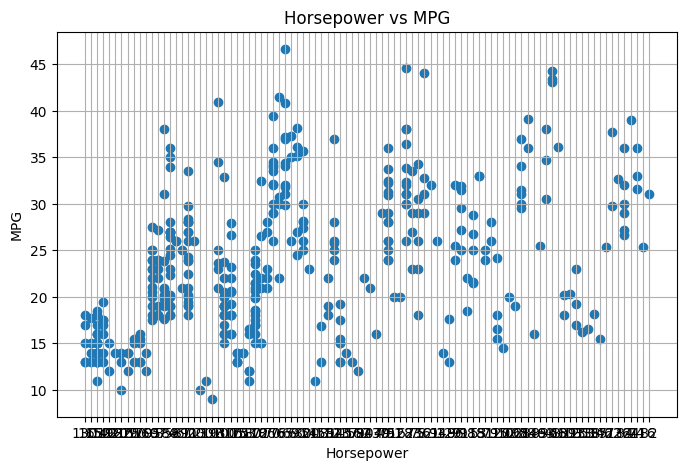

In [ ]:
# TASK 5: PLOT SCATTER GRAPH

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Horsepower vs MPG')
plt.grid(True)

plt.show()

In [ ]:
# TASK 6: ADD BIAS TERM

X_matrix = np.column_stack((np.ones(len(X)), X))

print("Design Matrix:")
print(X_matrix[:10])

print("\nDesign Matrix Shape:", X_matrix.shape)

Design Matrix:
[[1.0 '130']
 [1.0 '165']
 [1.0 '150']
 [1.0 '150']
 [1.0 '140']
 [1.0 '198']
 [1.0 '220']
 [1.0 '215']
 [1.0 '225']
 [1.0 '190']]

Design Matrix Shape: (398, 2)


In [ ]:
# TASK 7: COMPUTE CORRELATION

# Convert horsepower from string to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Remove rows where horsepower or mpg is missing
df = df.dropna(subset=['horsepower', 'mpg'])

# Select clean Horsepower and MPG values
X = df['horsepower'].values
y = df['mpg'].values

# Calculate correlation
correlation = np.corrcoef(X, y)[0, 1]

print("Correlation between Horsepower and MPG:", correlation)

Correlation between Horsepower and MPG: -0.7784267838977756


In [ ]:
# TASK 8: CALCULATE OLS WEIGHTS

X_matrix = np.column_stack((np.ones(len(X)), X))

w = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y

w0 = w[0]
w1 = w[1]

print("Intercept (w0):", w0)
print("Slope (w1):", w1)

print("\nRegression Equation:")
print(f"MPG = {w0:.4f} + ({w1:.4f}) × Horsepower")

Intercept (w0): 39.9358610211705
Slope (w1): -0.15784473335365387

Regression Equation:
MPG = 39.9359 + (-0.1578) × Horsepower


In [ ]:
# TASK 9: PREDICT VALUES

# Predict MPG using the OLS weights
y_pred = X_matrix @ w

print("First 10 Actual and Predicted MPG values:")

for i in range(10):
    print(f"Actual MPG: {y[i]:.2f} | Predicted MPG: {y_pred[i]:.2f}")

First 10 Actual and Predicted MPG values:
Actual MPG: 18.00 | Predicted MPG: 19.42
Actual MPG: 15.00 | Predicted MPG: 13.89
Actual MPG: 18.00 | Predicted MPG: 16.26
Actual MPG: 16.00 | Predicted MPG: 16.26
Actual MPG: 17.00 | Predicted MPG: 17.84
Actual MPG: 15.00 | Predicted MPG: 8.68
Actual MPG: 14.00 | Predicted MPG: 5.21
Actual MPG: 14.00 | Predicted MPG: 6.00
Actual MPG: 14.00 | Predicted MPG: 4.42
Actual MPG: 15.00 | Predicted MPG: 9.95


In [ ]:
# TASK 10: COMPUTE RESIDUALS

# Residual = Actual MPG - Predicted MPG
residuals = y - y_pred

print("First 10 Residuals:")

for i in range(10):
    print(f"Residual {i+1}: {residuals[i]:.2f}")

First 10 Residuals:
Residual 1: -1.42
Residual 2: 1.11
Residual 3: 1.74
Residual 4: -0.26
Residual 5: -0.84
Residual 6: 6.32
Residual 7: 8.79
Residual 8: 8.00
Residual 9: 9.58
Residual 10: 5.05


In [ ]:
# TASK 11: CALCULATE SSE

# SSE = Sum of Squared Errors
SSE = np.sum(residuals ** 2)

print("Sum of Squared Errors (SSE):", SSE)

Sum of Squared Errors (SSE): 9385.915871932419


In [ ]:
# MSE = SSE / Number of observations
n = len(y)

MSE = SSE / n

print("Number of observations:", n)
print("Mean Squared Error (MSE):", MSE)

Number of observations: 392
Mean Squared Error (MSE): 23.943662938603108


In [ ]:
# Total Sum of Squares
SST = np.sum((y - np.mean(y)) ** 2)

# R² formula
R2 = 1 - (SSE / SST)

print("R² Score:", R2)
print("R² Percentage:", R2 * 100, "%")

R² Score: 0.6059482578894348
R² Percentage: 60.59482578894348 %


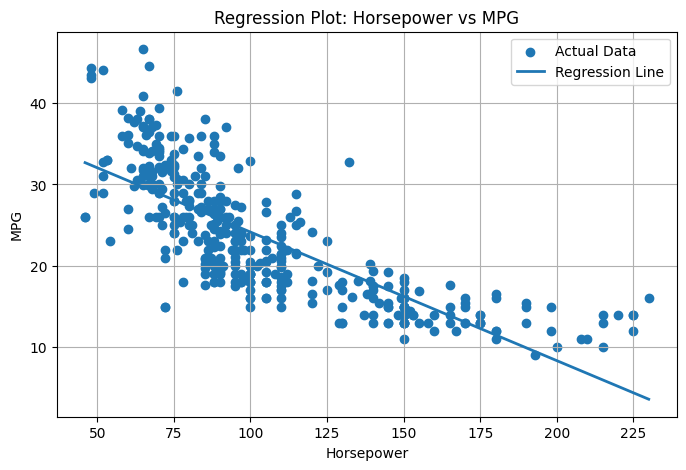

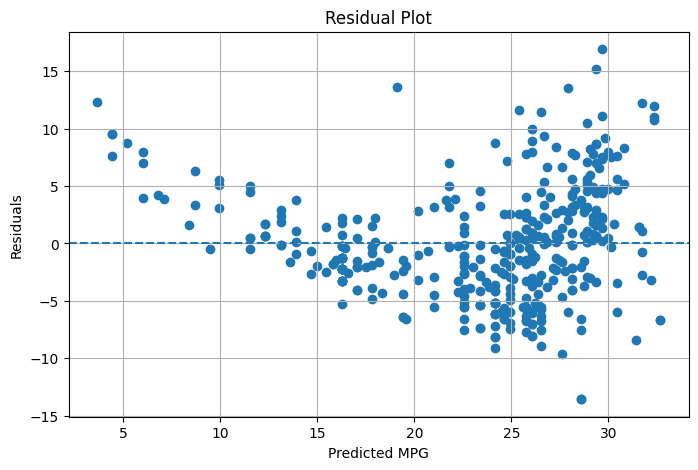

In [22]:
#TASK 12: PLOT REGRESSION AND RESIDUAL GRAPHS
# REGRESSION GRAPH

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot actual data
plt.scatter(X, y, label='Actual Data')

# Sort X values for a smooth regression line
sort_index = np.argsort(X)

# Plot regression line
plt.plot(
    X[sort_index],
    y_pred[sort_index],
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Regression Plot: Horsepower vs MPG')
plt.legend()
plt.grid(True)

plt.show()

#  RESIDUAL GRAPH

plt.figure(figsize=(8, 5))

# Plot residuals
plt.scatter(y_pred, residuals)

# Add zero reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted MPG')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)

plt.show()

In [21]:
# TASK 13: INTERPRET RESULTS

print("========== MODEL RESULTS ==========")

print(f"Correlation: {correlation:.4f}")
print(f"Intercept (w0): {w0:.4f}")
print(f"Slope (w1): {w1:.4f}")
print(f"SSE: {SSE:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"R²: {R2:.4f}")

print("\nRegression Equation:")
print(f"MPG = {w0:.4f} + ({w1:.4f}) × Horsepower")

print("\n========== INTERPRETATION ==========")

if correlation < 0:
    print("1. Horsepower and MPG have a negative relationship.")
else:
    print("1. Horsepower and MPG have a positive relationship.")

print(f"2. The slope is {w1:.4f}.")
print("   This means that as horsepower increases, MPG tends to decrease.")

print(f"3. The R² value is {R2:.4f}.")
print(f"   Therefore, horsepower explains approximately {R2 * 100:.2f}% of the variation in MPG.")

print("4. The regression graph shows a downward trend,")
print("   indicating that vehicles with higher horsepower generally have lower MPG.")

print("5. The residual plot helps evaluate the regression model.")
print("   Residuals should ideally be randomly distributed around zero.")

========== MODEL RESULTS ==========
Correlation: -0.7784
Intercept (w0): 39.9359
Slope (w1): -0.1578
SSE: 9385.9159
MSE: 23.9437
R²: 0.6059

Regression Equation:
MPG = 39.9359 + (-0.1578) × Horsepower

========== INTERPRETATION ==========
1. Horsepower and MPG have a negative relationship.
2. The slope is -0.1578.
   This means that as horsepower increases, MPG tends to decrease.
3. The R² value is 0.6059.
   Therefore, horsepower explains approximately 60.59% of the variation in MPG.
4. The regression graph shows a downward trend,
   indicating that vehicles with higher horsepower generally have lower MPG.
5. The residual plot helps evaluate the regression model.
   Residuals should ideally be randomly distributed around zero.


Conclusion:-

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
